# Image Enhancement Lab (Color Image Processing)
Run each cell separately for each technique.

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def load_image(path):
    img = cv2.imread(path)
    if img is None:
        raise Exception("Image not found!")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img.astype(np.float32) / 255.0

def show(img1, img2, title1="Input", title2="Output"):
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(img1)
    plt.title(title1)
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(img2)
    plt.title(title2)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

img = load_image("high boost.jpg")


## Image Negative

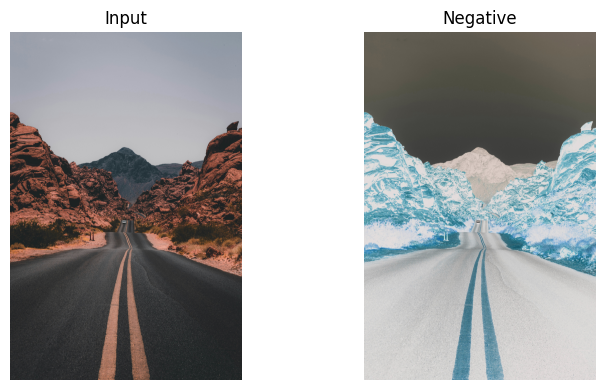

In [2]:
negative = 1 - img
show(img, negative, 'Input', 'Negative')

## Log Transformation

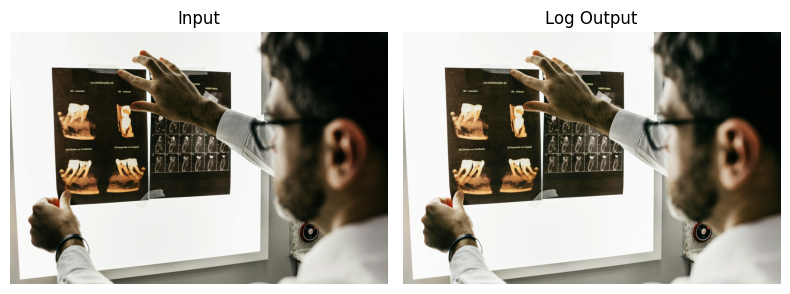

In [6]:
log_img = np.log(1 + img)
log_img = log_img / np.max(log_img)
show(img, log_img, 'Input', 'Log Output')

## Gamma Transformation

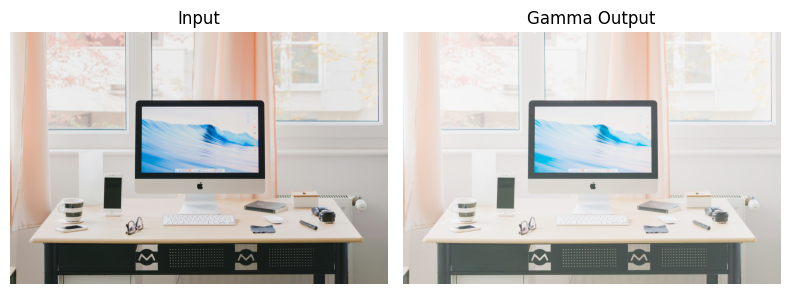

In [8]:
gamma_img = np.power(img, 0.5)
show(img, gamma_img, 'Input', 'Gamma Output')

## Contrast Stretching

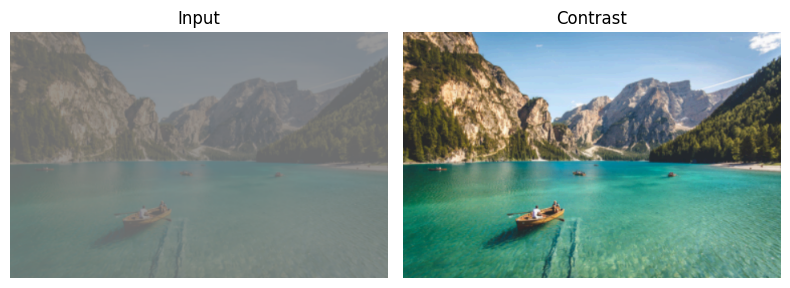

In [20]:
contrast = (img - img.min()) / (img.max() - img.min())
show(img, contrast, 'Input', 'Contrast')

## Bit Plane (Color)

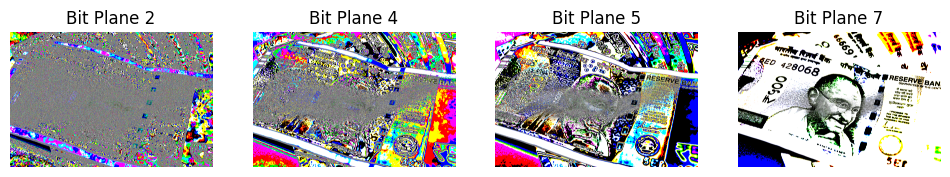

In [13]:


R = (img[:,:,0]*255).astype(np.uint8)
G = (img[:,:,1]*255).astype(np.uint8)
B = (img[:,:,2]*255).astype(np.uint8)

ks = [2,4,5,7]

plt.figure(figsize=(12,6))

for i, k in enumerate(ks):
    r = ((R >> k) & 1) * 255
    g = ((G >> k) & 1) * 255
    b = ((B >> k) & 1) * 255

    bit_plane = np.stack([r,g,b], axis=2) / 255.0

    plt.subplot(1, len(ks), i+1)
    plt.imshow(bit_plane)
    plt.title(f"Bit Plane {k}")
    plt.axis('off')

plt.show()

## Histogram Enhancement

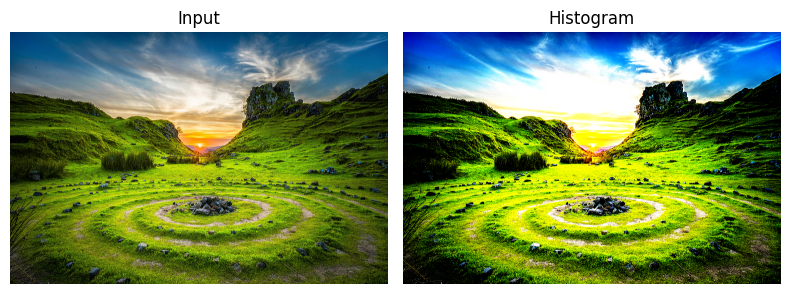

In [22]:
mean = np.mean(img)
std = np.std(img)
hist_img = img + 0.5*(img-mean)/(std+1e-8)
hist_img = np.clip(hist_img,0,1)
show(img, hist_img, 'Input', 'Histogram')

## Box Filter

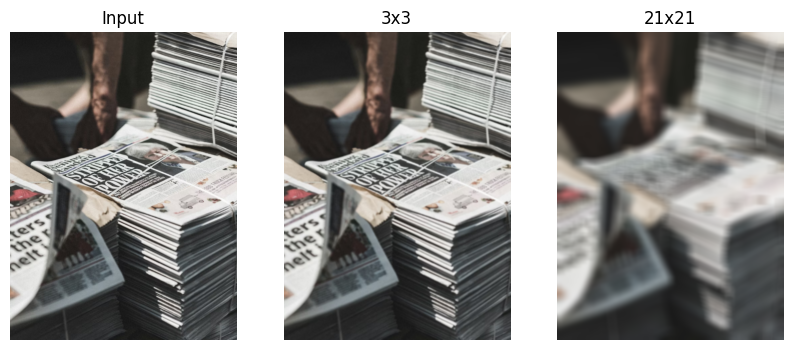

In [27]:
box3 = cv2.blur(img, (3,3))
box21 = cv2.blur(img, (21,21))

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(img); plt.title("Input"); plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(box3); plt.title("3x3"); plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(box21); plt.title("21x21"); plt.axis('off')

plt.show()

## Gaussian Filter

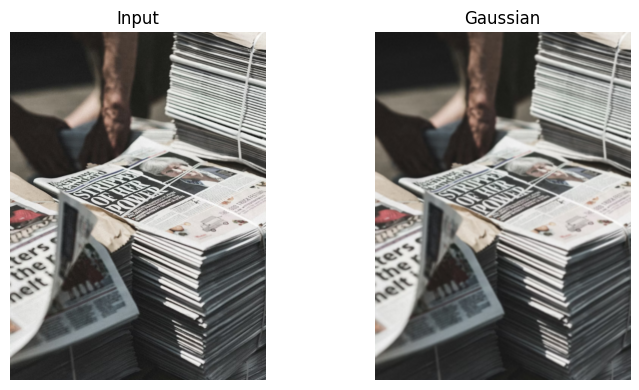

In [28]:
gauss = cv2.GaussianBlur(img,(5,5),1)
show(img, gauss, 'Input', 'Gaussian')

## Shading Correction

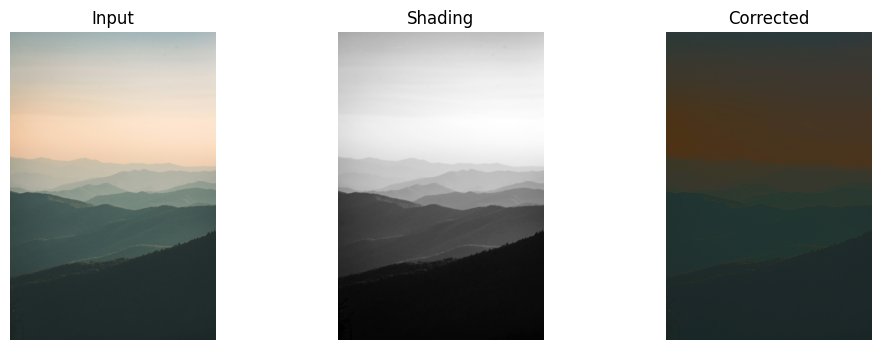

In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show(img1, img2, img3):
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img1)
    plt.title("Input")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(img2, cmap='gray')
    plt.title("Shading")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(img3)
    plt.title("Corrected")
    plt.axis('off')

    plt.show()



img = cv2.imread("shading coorection.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
l, a, b = cv2.split(lab)

l = l.astype(np.float32) / 255.0

blur = cv2.GaussianBlur(l, (21,21), 5)

l_corrected = l / (blur + 0.05)
l_corrected = np.power(l_corrected, 0.8)

l_corrected = cv2.normalize(l_corrected, None, 0, 1, cv2.NORM_MINMAX)

l_corrected = (l_corrected * 255).astype(np.uint8)

lab_corrected = cv2.merge([l_corrected, a, b])
corrected = cv2.cvtColor(lab_corrected, cv2.COLOR_LAB2RGB)

show(img, blur, corrected)

## Laplacian Sharpening

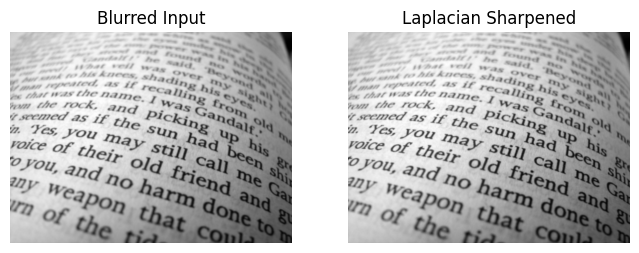

In [24]:
alpha = 1.0

gray = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
gray = gray.astype(np.float32) / 255.0

blurred = cv2.GaussianBlur(gray, (9,9), 0)

lap = cv2.Laplacian(blurred, cv2.CV_32F)

sharp = np.clip(blurred - alpha * lap, 0, 1)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(blurred, cmap='gray')
plt.title("Blurred Input")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(sharp, cmap='gray')
plt.title("Laplacian Sharpened")
plt.axis('off')

plt.show()

## High Boost Filtering

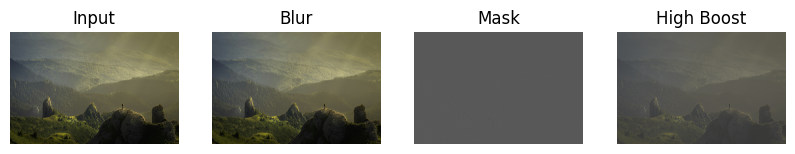

In [27]:
blur = cv2.GaussianBlur(img, (11,11), 3)

mask = img - blur

mask_display = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)

k = 2.0
high_boost = img + k * mask

high_boost = (high_boost - high_boost.min()) / (high_boost.max() - high_boost.min() + 1e-8)

plt.figure(figsize=(10,4))

plt.subplot(1,4,1)
plt.imshow(img); plt.title("Input"); plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(blur); plt.title("Blur"); plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(mask_display); plt.title("Mask"); plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(high_boost); plt.title("High Boost"); plt.axis('off')

plt.show()